# DRAGONS-compatible version of IGRINS2 pipeline

<div class="alert alert-success">
DRAGONS-compatible version is in very early stage of development. This is largely a translation of original IGRINS plp pipeline to the DRAGONS framework. For now, it supports H and K band spectra, and the results should be comparable to that of the plp version of the pipeline.
</div>

<div class="alert alert-success">
At this stage of development, plesae understand that the primary purpose of this document is to receive (early) feedback on high-level workflow. But any comment will be welcomed.
</div>


## Install

Please consult :doc:`INSTALL` to install IGRINSDR.


## Setting up

The original version of this document is a jupyter notebook, mixed with shell comannds and python code. It may be better to look at the original notebook file.

To reduce number of typing, we make aliases for `dataselect` and `reduce` so that they load ingrisdr packages automtically.


On the shell, you may do something like

```sh
> alias dataselect_ig="dataselect --adpkg=igrins_instruments"
> alias reduce_ig="reduce --drpkg=igrinsdr --adpkg=igrins_instruments"
```

Below we will us ipython magic commands for aliasing.

In [4]:
alias dataselect_ig dataselect --adpkg=igrins_instruments

In [5]:
alias reduce_ig reduce --drpkg=igrinsdr --adpkg=igrins_instruments

Below are initial import statements for the pyton codes.

In [6]:
import astrodata
import numpy as np
import matplotlib.pyplot as plt

import astrodata

## Download data

We will use engineering data of "gn-2024a-eng-142" which is available from
Gemini archive. Download data from 2024-04-29.

The MEF files from the archive need to be unbundled to H and K bands files. Assuming that files from gemini archive is extracted in the directory "mef_20240429" (the files need to be unzipped if zipped). 'reduce' can be used to unbundle these files.

```bash
> dataselect_ig --tags BUNDLE mef_20240429/N*.fits -o list_of_bundles.txt
> reduce_ig @list_of_bundles.txt
```

For the commands below, we will temporarily cd to `unbundled_20240429`. The unbundled files will be saved in the working directory.

In [8]:
!mkdir unbundled_20240429
%cd unbundled_20240429

/home/jjlee/git_personal/IGRINSDR/test_i2/unbundled_20240429


In [9]:
%dataselect_ig --tags BUNDLE ../mef_20240429/N*.fits -o list_of_bundles.txt

In [10]:
!cat list_of_bundles.txt

# Includes tags: ['BUNDLE']
# Excludes tags: []
# Descriptor expression: None
../mef_20240429/N20240429S0120.fits
../mef_20240429/N20240429S0121.fits
../mef_20240429/N20240429S0122.fits
../mef_20240429/N20240429S0123.fits
../mef_20240429/N20240429S0124.fits
../mef_20240429/N20240429S0125.fits
../mef_20240429/N20240429S0126.fits
../mef_20240429/N20240429S0127.fits
../mef_20240429/N20240429S0128.fits
../mef_20240429/N20240429S0188.fits
../mef_20240429/N20240429S0189.fits
../mef_20240429/N20240429S0190.fits
../mef_20240429/N20240429S0191.fits
../mef_20240429/N20240429S0192.fits
../mef_20240429/N20240429S0193.fits
../mef_20240429/N20240429S0194.fits
../mef_20240429/N20240429S0195.fits
../mef_20240429/N20240429S0196.fits
../mef_20240429/N20240429S0197.fits
../mef_20240429/N20240429S0204.fits
../mef_20240429/N20240429S0365.fits
../mef_20240429/N20240429S0366.fits
../mef_20240429/N20240429S0367.fits
../mef_20240429/N20240429S0368.fits
../mef_20240429/N20240429S0369.fits
../mef_20240429/N20240

In [11]:
%reduce_ig @list_of_bundles.txt


			--- reduce v4.1.0 ---

Running on Python 3.12.12
All submitted files appear valid:
../mef_20240429/N20240429S0120.fits ... ../mef_20240429/N20240429S0384.fits, 40 files submitted.
RECIPE: processBundle
   PRIMITIVE: splitBundle
   ----------------------
   Splitting N20240429S0120.fits
   Splitting N20240429S0121.fits
   Splitting N20240429S0122.fits
   Splitting N20240429S0123.fits
   Splitting N20240429S0124.fits
   Splitting N20240429S0125.fits
   Splitting N20240429S0126.fits
   Splitting N20240429S0127.fits
   Splitting N20240429S0128.fits
   Splitting N20240429S0188.fits
   Splitting N20240429S0189.fits
   Splitting N20240429S0190.fits
   Splitting N20240429S0191.fits
   Splitting N20240429S0192.fits
   Splitting N20240429S0193.fits
   Splitting N20240429S0194.fits
   Splitting N20240429S0195.fits
   Splitting N20240429S0196.fits
   Splitting N20240429S0197.fits
   Splitting N20240429S0204.fits
   Splitting N20240429S0365.fits
   Splitting N20240429S0366.fits
   Splitting N20

In [12]:
%cd -

/home/jjlee/git_personal/IGRINSDR/test_i2


In [2]:
# This require igrinsdr_helper to be installed (pip install igrinsdr-helper)
from igrinsdr_helper.igrinsdr_tree import get_ad_tree
from pathlib import Path

get_ad_tree(Path("./unbundled_20240429").glob("N*_H.fits"))

Tree(nodes=(Node(icon_style='success', name="'SPECT UNPREPARED NORTH IGRINS GEMINI H IGRINS-2'", nodes=(Node(i…

## Running REDUCE
1. FLAT
2. SKY
3. STANDARD
4. TARGET

## FLAT

Then create a file lising the FALT image from the fixed fits files.

> dataselect_ig --tags FLAT,H unbundled_20240429/N*_H.fits -o list_of_flat_h.txt

For now, you need to make a badpixel file using the flat images. For this, you will the reduce with a specific recipe name.

> reduce_ig @list_of_flat_h.txt -r makeProcessedBPM


Run reduce_ig with the name of the created badpixel file as a parameter.

> reduce_ig @list_of_flat_h.txt -p user_bpm=SDCH_20240429_0365_hotpixel.fits



In [7]:
%dataselect_ig --tags FLAT,H unbundled_20240429/N*_H.fits -o list_of_flat_h.txt

In [8]:
!cat list_of_flat_h.txt

# Includes tags: ['FLAT', 'H']
# Excludes tags: []
# Descriptor expression: None
unbundled_20240429/N20240429S0365_H.fits
unbundled_20240429/N20240429S0366_H.fits
unbundled_20240429/N20240429S0367_H.fits
unbundled_20240429/N20240429S0368_H.fits
unbundled_20240429/N20240429S0369_H.fits
unbundled_20240429/N20240429S0370_H.fits
unbundled_20240429/N20240429S0371_H.fits
unbundled_20240429/N20240429S0372_H.fits
unbundled_20240429/N20240429S0373_H.fits
unbundled_20240429/N20240429S0374_H.fits
unbundled_20240429/N20240429S0375_H.fits
unbundled_20240429/N20240429S0376_H.fits
unbundled_20240429/N20240429S0377_H.fits
unbundled_20240429/N20240429S0378_H.fits
unbundled_20240429/N20240429S0379_H.fits
unbundled_20240429/N20240429S0380_H.fits
unbundled_20240429/N20240429S0381_H.fits
unbundled_20240429/N20240429S0382_H.fits
unbundled_20240429/N20240429S0383_H.fits
unbundled_20240429/N20240429S0384_H.fits


In [9]:
%reduce_ig @list_of_flat_h.txt -r makeProcessedBPM


			--- reduce v4.1.0 ---

Running on Python 3.12.12
All submitted files appear valid:
unbundled_20240429/N20240429S0365_H.fits ... unbundled_20240429/N20240429S0384_H.fits, 20 files submitted.
RECIPE: makeProcessedBPM
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         .
      .
      PRIMITIVE: standardizeWCS
      -------------------------
      .
   .
   PRIMITIVE: addDQ
   ----------------
   No BPMs found for N20240429S0365_H_prepared.fits and none supplied by the user.
   
   No BPMs found fo

In [10]:
%reduce_ig @list_of_flat_h.txt -p user_bpm=N20240429S0365_H_badpixel.fits


			--- reduce v4.1.0 ---

Running on Python 3.12.12
All submitted files appear valid:
unbundled_20240429/N20240429S0365_H.fits ... unbundled_20240429/N20240429S0384_H.fits, 20 files submitted.
RECIPE: makeProcessedFlat
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         .
      .
      PRIMITIVE: standardizeWCS
      -------------------------
      .
   .
   PRIMITIVE: readoutPatternCorrectFlatOff
   ---------------------------------------
      PRIMITIVE: selectFromInputs
      -------------------

In [11]:
ad_flat = astrodata.open("N20240429S0375_H_flat.fits")
ad_flat.info()

Filename: N20240429S0375_H_flat.fits
Tags: CAL FLAT GCALFLAT GEMINI H IGRINS IGRINS-2 NORTH PREPARED PROCESSED SPECT

Pixels Extensions
Index  Content                  Type              Dimensions     Format
[ 0]   science                  NDAstroData       (2048, 2048)   float64
          .variance             ADVarianceUncerta (2048, 2048)   float32
          .mask                 ndarray           (2048, 2048)   uint16
          .FLAT_ORIGINAL        ndarray           (2048, 2048)   float32
          .SLITEDGE             Table             (54, 6)        n/a

Other Extensions
               Type        Dimensions
.FLATNORM      Table       (3, 3)
.HISTORY       Table       (8, 4)
.PROVENANCE    Table       (21, 4)


In [12]:
%matplotlib inline

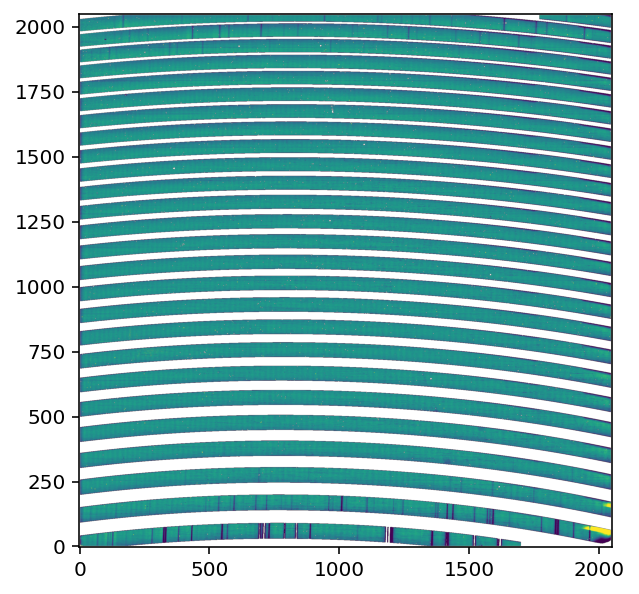

In [13]:
plt.figure()
plt.imshow(np.ma.array(ad_flat[0].data, mask=ad_flat[0].mask).filled(np.nan), vmin=0.8, vmax=1.2, origin="lower")

## SKY

(this recipe is a combined version of register-sky and wvlsol-sky from the PLP)

Create a file containg sky frames.

> dataselect_ig --tags SKY,H unbundled_20240429/N*_H.fits -o list_of_sky_h.txt

<div class="alert alert-info">
CALDB support is not properly integrated yet. You need to explicitly speicy calibrations file with the "--user_cal" options.
</div>

We will run reduce, but we need to explicitly set the calibration file.

> reduce_ig @list_of_sky_h.txt --user_cal processed_flat:SDCH_20240429_0375_flat.fits


In [14]:
%dataselect_ig --tags SKY,H unbundled_20240429/N*_H.fits -o list_of_sky_h.txt

In [15]:
!cat list_of_sky_h.txt

# Includes tags: ['SKY', 'H']
# Excludes tags: []
# Descriptor expression: None
unbundled_20240429/N20240429S0204_H.fits


In [16]:
%reduce_ig @list_of_sky_h.txt --user_cal processed_flat:N20240429S0375_H_flat.fits


			--- reduce v4.1.0 ---

Running on Python 3.12.12
All submitted files appear valid:
unbundled_20240429/N20240429S0204_H.fits
Manually assigned N20240429S0375_H_flat.fits as processed_flat
RECIPE: makeProcessedArc
   PRIMITIVE: fixIgrinsHeader
   --------------------------
   .
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         .
      .
      PRIMITIVE: standardizeWCS
      -------------------------
      WARNING - N20240429S0204_H_observatoryHeadersStandardized.fits (and maybe other files) do n

In [17]:
ad_sky = astrodata.open("N20240429S0204_H_arc.fits")
ad_sky.info()

Filename: N20240429S0204_H_arc.fits
Tags: ARC CAL GEMINI H IGRINS IGRINS-2 NORTH PREPARED PROCESSED SIDEREAL SPECT

Pixels Extensions
Index  Content                  Type              Dimensions     Format
[ 0]   science                  NDAstroData       (2048, 2048)   float32
          .variance             ADVarianceUncerta (2048, 2048)   float32
          .mask                 ndarray           (2048, 2048)   uint16
          .FLEXCORR             ndarray           (2048, 2048)   float32
          .LINEFIT              Table             (755, 10)      n/a
          .LINEID               Table             (1311, 4)      n/a
          .ORDERMAP             ndarray           (2048, 2048)   int32
          .SLITEDGE             Table             (54, 6)        n/a
          .SLITOFFSETMAP        ndarray           (2048, 2048)   float64
          .SLITPOSMAP           ndarray           (2048, 2048)   float64
          .SPEC1D               Table             (27, 4)        n/a
          

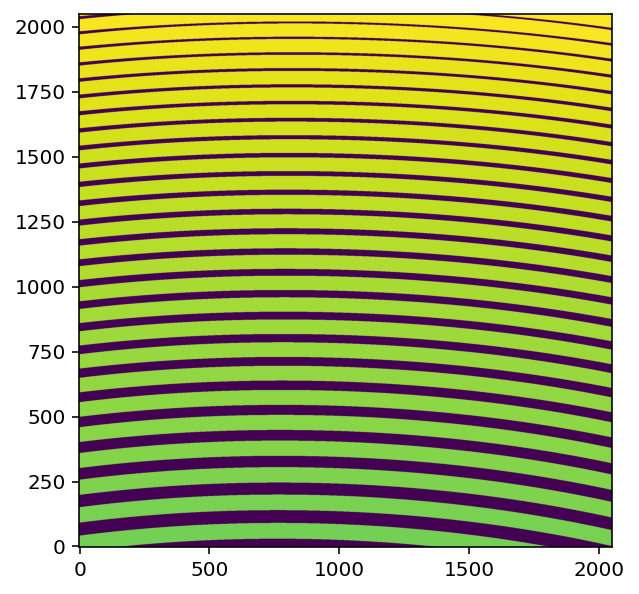

In [18]:
plt.figure()
plt.imshow(ad_sky[0].ORDERMAP, origin="lower")

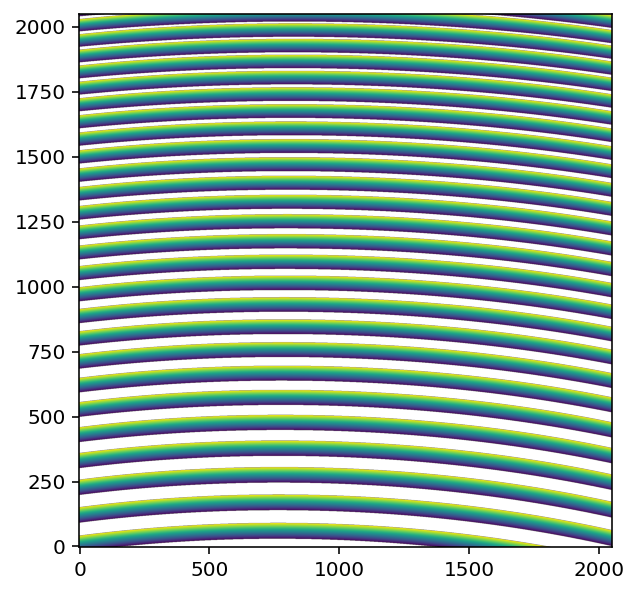

In [19]:
plt.figure()
plt.imshow(ad_sky[0].SLITPOSMAP, origin="lower")

In [20]:
ad_sky[0].WVLSOL

orders,wavelengths
int64,float64[2048]
98,1.8111782542108175 .. 1.8360355144088847
99,1.7933426895060407 .. 1.8179597713646614
100,1.7758681385798152 .. 1.8002494404830163
101,1.7587439812773917 .. 1.782893672643976
102,1.7419600139206783 .. 1.7658820441832508
103,1.7255064290909259 .. 1.7492045362390494
104,1.7093737965777989 .. 1.7328515152904171
105,1.6935530454170697 .. 1.7168137148076754
106,1.6780354469450487 .. 1.7010822179415082


## A0V

Let's do telluric standar star. We will select images from observation_id of
'GN-2024A-ENG-142-261'.

> dataselect_ig --tags STANDARD,H unbundled_20240429/N*_H.fits -o list_of_std_h.txt --expr "observation_id=='GN-2024A-ENG-142-120'"

Again, we need to explicitly specify calibration files.

> reduce_ig @list_of_std_h.txt --user_cal processed_flat:N20240429S0375_H_flat processed_arc:N20240429S0204_H_arc.fits



In [21]:
%dataselect_ig --tags STANDARD,H unbundled_20240429/N*_H.fits -o list_of_std_h.txt --expr "observation_id=='GN-2024A-ENG-142-120'"

In [22]:
!cat list_of_std_h.txt

# Includes tags: ['STANDARD', 'H']
# Excludes tags: []
# Descriptor expression: observation_id=='GN-2024A-ENG-142-120'
unbundled_20240429/N20240429S0194_H.fits
unbundled_20240429/N20240429S0195_H.fits
unbundled_20240429/N20240429S0196_H.fits
unbundled_20240429/N20240429S0197_H.fits


In [23]:
%reduce_ig @list_of_std_h.txt --user_cal processed_flat:N20240429S0375_H_flat.fits processed_arc:N20240429S0204_H_arc.fits


			--- reduce v4.1.0 ---

Running on Python 3.12.12
All submitted files appear valid:
unbundled_20240429/N20240429S0194_H.fits ... unbundled_20240429/N20240429S0197_H.fits, 4 files submitted.
Manually assigned N20240429S0375_H_flat.fits as processed_flat
Manually assigned N20240429S0204_H_arc.fits as processed_arc
RECIPE: makeStd
   PRIMITIVE: checkCALDB
   ---------------------
   .
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         .
      .
      PRIMITIVE: standardizeWCS
      ----------------

In [24]:
ad_std = astrodata.open("N20240429S0194_H_spec1d.fits")
ad_std.info()

Filename: N20240429S0194_H_spec1d.fits
Tags: CAL GEMINI H IGRINS IGRINS-2 NORTH PREPARED SIDEREAL SPECT STANDARD

Pixels Extensions
Index  Content                  Type              Dimensions     Format
[ 0]   science                  NDAstroData       (27, 2048)     float64
          .variance             ADVarianceUncerta (27, 2048)     float64
          .SN_PER_RESEL         ndarray           (27, 2048)     float64
          .WAVELENGTHS          ndarray           (27, 2048)     float64


[Text(0.5, 0, 'wavelength axis'), Text(0, 0.5, 'order axis')]

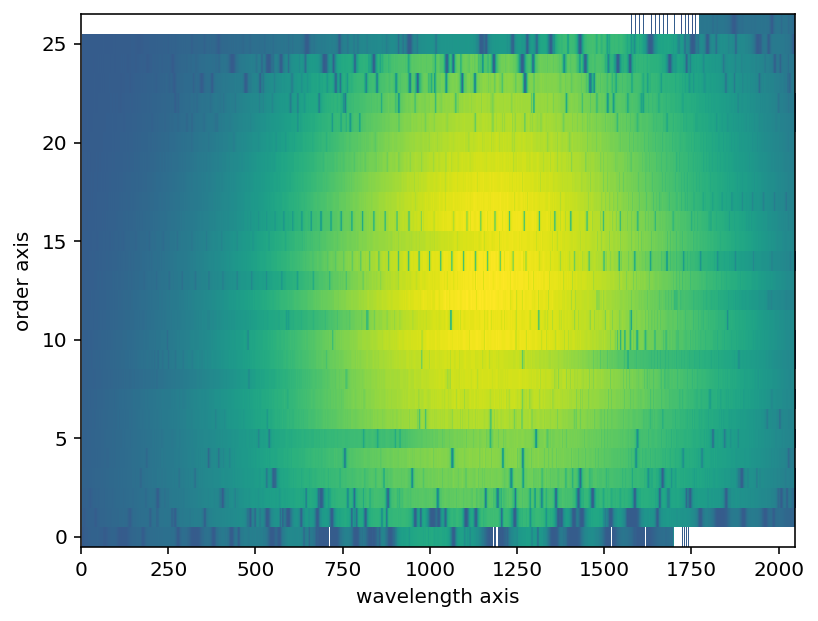

In [25]:
plt.figure()
plt.imshow(ad_std[0].data, origin="lower", aspect="auto", interpolation="none")
plt.gca().set(xlabel="wavelength axis", ylabel="order axis")

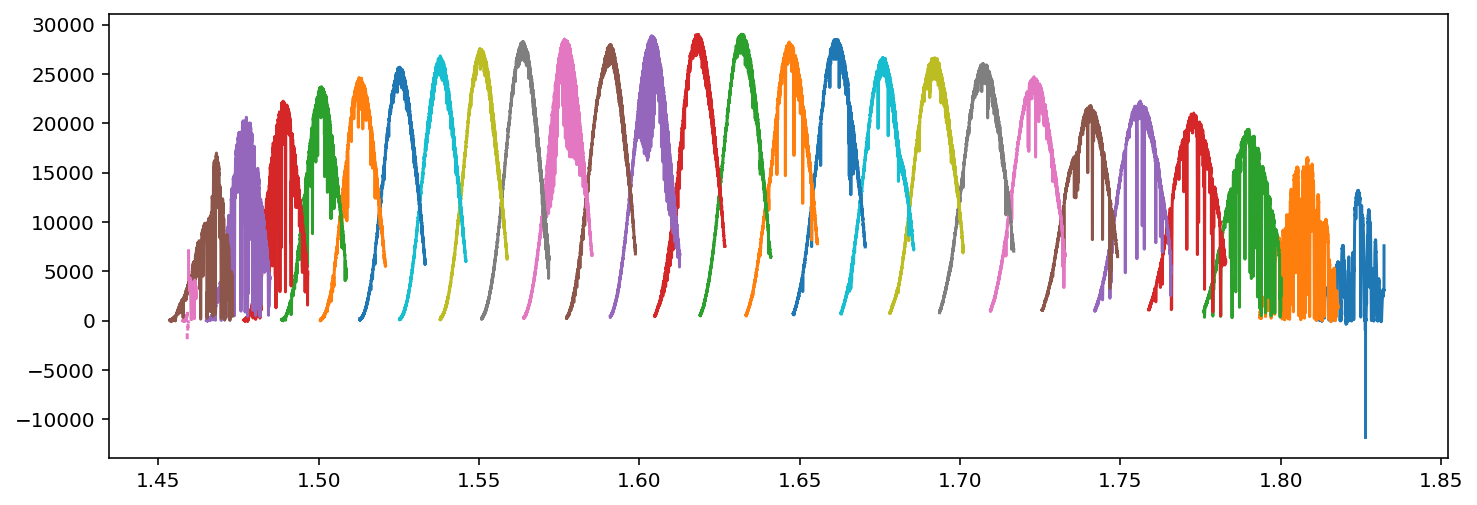

In [26]:
fig, ax = plt.subplots(figsize=(12, 4))
for w, s in zip(ad_std[0].WAVELENGTHS, ad_std[0].data):
    ax.plot(w[6:-6], s[6:-6])


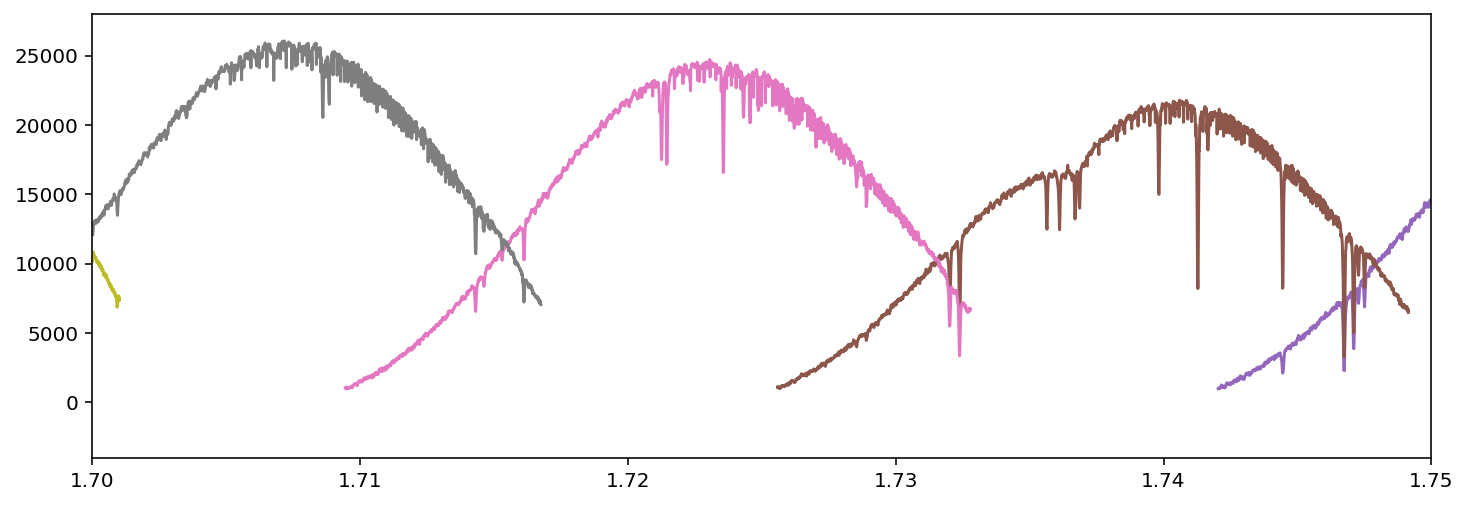

In [27]:
ax.set_xlim(1.7, 1.75)
ax.set_ylim(-4000, 28000)
fig

In [28]:
ad_std_2dspec = astrodata.open("N20240429S0194_H_spec2d.fits")
ad_std_2dspec.info()

Filename: N20240429S0194_H_spec2d.fits
Tags: CAL GEMINI H IGRINS IGRINS-2 NORTH PREPARED SIDEREAL SPECT STANDARD

Pixels Extensions
Index  Content                  Type              Dimensions     Format
[ 0]   science                  NDAstroData       (27, 63, 2048) float32
          .variance             ADVarianceUncerta (27, 63, 2048) float64
          .WAVELENGTHS          ndarray           (27, 2048)     float64


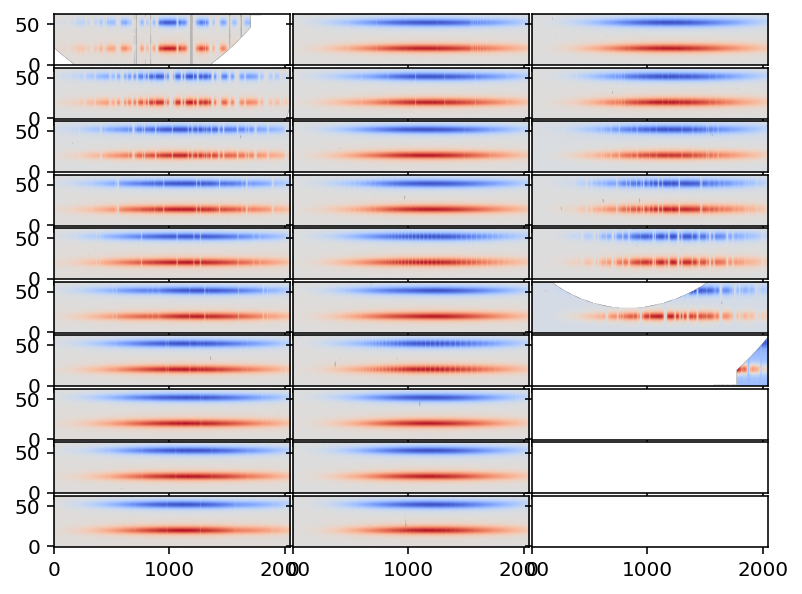

In [29]:
from mpl_toolkits.axes_grid1 import Grid
fig = plt.figure()
grid = Grid(fig, 111, (10, 3), direction="column")
for ax, im in zip(grid, ad_std_2dspec[0].data):
    ax.imshow(im, origin="lower", aspect="auto", cmap="coolwarm")


In [30]:
ad_std_debug = astrodata.open("N20240429S0194_H_spec_debug.fits")
ad_std_debug.info()

Filename: N20240429S0194_H_spec_debug.fits
Tags: CAL GEMINI H IGRINS IGRINS-2 NORTH PREPARED SIDEREAL SPECT STANDARD

Pixels Extensions
Index  Content                  Type              Dimensions     Format
[ 0]   science                  NDAstroData       (2048, 2048)   float64
          .variance             ADVarianceUncerta (2048, 2048)   float64
          .mask                 ndarray           (2048, 2048)   uint16
          .SLITPROFILE_MAP      ndarray           (2048, 2048)   float64
          .SPEC1D               Table             (27, 5)        n/a
          .WVLCOR               Table             (4, 2)         n/a


## SCIENCE

For science target, select 900078.

> dataselect_ig --tags SCIENCE,H unbundled_20240429/N*_H.fits -o list_of_900078_h.txt --expr "object=='900078'"

Run reduce.

> reduce_ig @list_of_900078_h.txt --user_cal processed_flat:N20240429S0375_H_flat.fits processed_arc:N20240429S0204_H_arc.fits



In [31]:
%dataselect_ig --tags SIDEREAL,H unbundled_20240429/N*_H.fits -o list_of_900078_h.txt --expr "object=='900078'"

In [32]:
!cat list_of_900078_h.txt

# Includes tags: ['SIDEREAL', 'H']
# Excludes tags: []
# Descriptor expression: object=='900078'
unbundled_20240429/N20240429S0190_H.fits
unbundled_20240429/N20240429S0191_H.fits
unbundled_20240429/N20240429S0192_H.fits
unbundled_20240429/N20240429S0193_H.fits


In [33]:
%reduce_ig @list_of_900078_h.txt --user_cal processed_flat:N20240429S0375_H_flat.fits processed_arc:N20240429S0204_H_arc.fits


			--- reduce v4.1.0 ---

Running on Python 3.12.12
All submitted files appear valid:
unbundled_20240429/N20240429S0190_H.fits ... unbundled_20240429/N20240429S0193_H.fits, 4 files submitted.
Manually assigned N20240429S0375_H_flat.fits as processed_flat
Manually assigned N20240429S0204_H_arc.fits as processed_arc
RECIPE: makeTgt
   PRIMITIVE: checkCALDB
   ---------------------
   .
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         .
      .
      PRIMITIVE: standardizeWCS
      ----------------

In [34]:
ad_tgt = astrodata.open("N20240429S0190_H_spec1d.fits")
ad_tgt.info()

Filename: N20240429S0190_H_spec1d.fits
Tags: GEMINI H IGRINS IGRINS-2 NORTH PREPARED SIDEREAL SPECT

Pixels Extensions
Index  Content                  Type              Dimensions     Format
[ 0]   science                  NDAstroData       (27, 2048)     float64
          .variance             ADVarianceUncerta (27, 2048)     float64
          .SN_PER_RESEL         ndarray           (27, 2048)     float64
          .WAVELENGTHS          ndarray           (27, 2048)     float64


[Text(0.5, 0, 'wavelength axis'), Text(0, 0.5, 'order axis')]

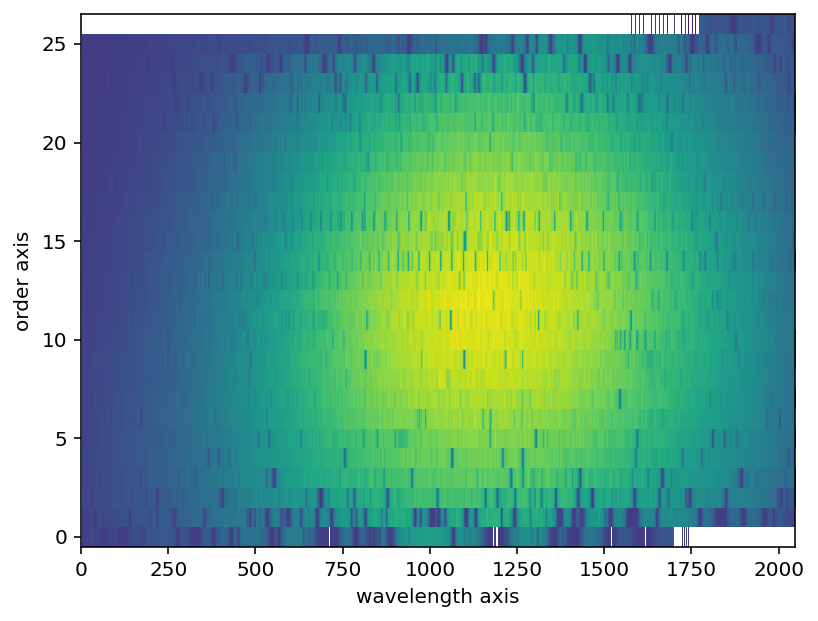

In [35]:
plt.imshow(ad_tgt[0].data, origin="lower", aspect="auto", interpolation="none")
plt.gca().set(xlabel="wavelength axis", ylabel="order axis")

(0.0, 0.7)

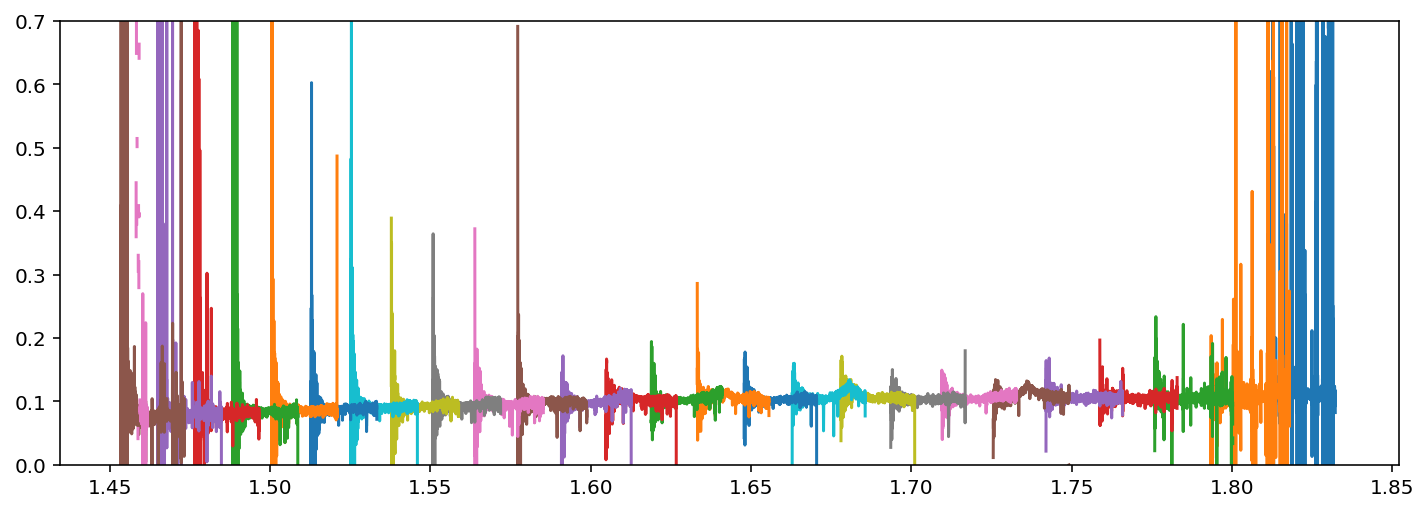

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))
for w, s, t in zip(ad_std[0].WAVELENGTHS, ad_std[0].data, ad_tgt[0].data):
    ax.plot(w, t/s)
ax.set_ylim(0., 0.7)

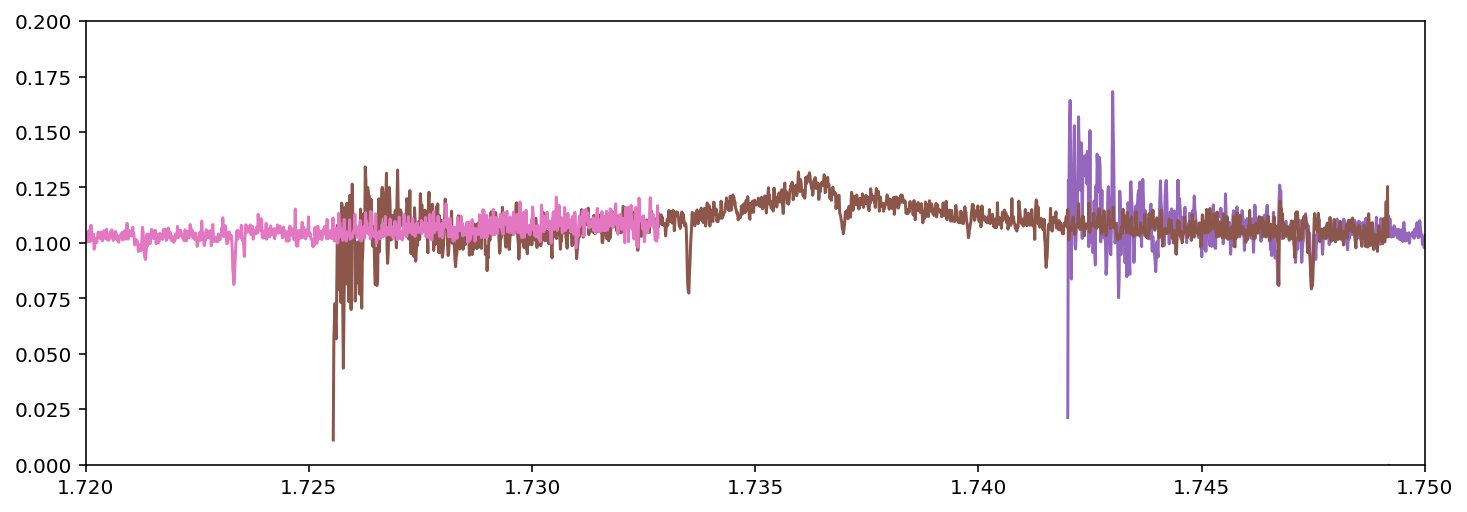

In [37]:
ax.set_xlim(1.72, 1.75)
ax.set_ylim(0., 0.2)
fig